# Retail Demand Forecasting & Inventory Replenishment Planner

This notebook summarizes:
- demand trends
- promo / holiday effects
- top SKUs
- forecast performance
- inventory risk
- replenishment recommendations
- impact estimation

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["axes.grid"] = True

In [4]:
# Detect project root automatically

BASE_DIR = Path.cwd()

if (BASE_DIR / "analysis").exists():
    # notebook opened from project root
    PROJECT_ROOT = BASE_DIR
else:
    # notebook opened from inside analysis folder
    PROJECT_ROOT = BASE_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR = PROJECT_ROOT / "analysis" / "outputs"

print("PROJECT ROOT:", PROJECT_ROOT)
print("DATA DIR:", DATA_DIR)
print("OUTPUT DIR:", OUT_DIR)

PROJECT ROOT: c:\Users\praga\dubai class\PragatikaMishra_Capstone_RetailForecastReplenishment
DATA DIR: c:\Users\praga\dubai class\PragatikaMishra_Capstone_RetailForecastReplenishment\data
OUTPUT DIR: c:\Users\praga\dubai class\PragatikaMishra_Capstone_RetailForecastReplenishment\analysis\outputs


In [5]:


fact_sales = pd.read_csv(DATA_DIR / "fact_sales_store_sku_daily.csv", parse_dates=["date"])
fact_inventory = pd.read_csv(DATA_DIR / "fact_inventory_store_sku_daily.csv", parse_dates=["date"])
repl_inputs = pd.read_csv(DATA_DIR / "replenishment_inputs_store_sku.csv")

forecast_detail = pd.read_csv(OUT_DIR / "forecast_detail_28d.csv", parse_dates=["date"])
forecast_metrics = pd.read_csv(OUT_DIR / "forecast_metrics_store_sku.csv")
forecast_overall = pd.read_csv(OUT_DIR / "forecast_metrics_overall.csv")
forecast_by_category = pd.read_csv(OUT_DIR / "forecast_metrics_by_category.csv")

risk = pd.read_csv(OUT_DIR / "inventory_risk_segmented.csv")
stockout_top10 = pd.read_csv(OUT_DIR / "top10_stockout_risk.csv")
overstock_top10 = pd.read_csv(OUT_DIR / "top10_overstock_risk.csv")

policy = pd.read_csv(OUT_DIR / "replenishment_policy_store_sku.csv")
po_list = pd.read_csv(OUT_DIR / "recommended_po_list_next_cycle.csv")

impact_summary = pd.read_csv(OUT_DIR / "impact_projection_summary_by_scenario.csv")
impact_category = pd.read_csv(OUT_DIR / "impact_projection_by_category_base_case.csv")
top_impact = pd.read_csv(OUT_DIR / "top_impact_store_sku_base_case.csv")

kpi_summary = pd.read_csv(OUT_DIR / "kpi_summary.csv")

In [6]:
# quick sanity checks

fact_sales.head(), fact_inventory.head(), repl_inputs.head()

(        date store_id   sku_id region  city_tier store_size      category  \
 0 2025-07-04    ST001  SKU0001   WEST          3          M  Personalcare   
 1 2025-07-04    ST001  SKU0002   WEST          3          M      Homecare   
 2 2025-07-04    ST001  SKU0003   WEST          3          M        Snacks   
 3 2025-07-04    ST001  SKU0004   WEST          3          M        Snacks   
 4 2025-07-04    ST001  SKU0005   WEST          3          M     Beverages   
 
     price    cost  shelf_life_days  moq_units  units_sold  true_demand_units  \
 0  392.55  269.72              510         12           3                  3   
 1  372.13  210.62              536         12           4                  4   
 2  220.56  169.92              396         48           8                  8   
 3  539.79  385.07              420         24          10                 10   
 4  262.43  175.54              373         12           5                  5   
 
    stockout_censored_units  revenue  marg

In [7]:
# KPI summary

kpi_summary.T

,0
total_units_sold,2.069930e+05
total_true_demand_units,2.666011e+06
stockout_censored_units,2.460747e+06
total_revenue,5.445118e+07
total_margin_proxy,1.699559e+07
stockout_rate,9.202592e-01
fill_rate_proxy,7.699293e-02
avg_days_of_inventory_on_hand,6.193411e-01
overstock_rate,0.000000e+00
inventory_value_proxy,2.894888e+04


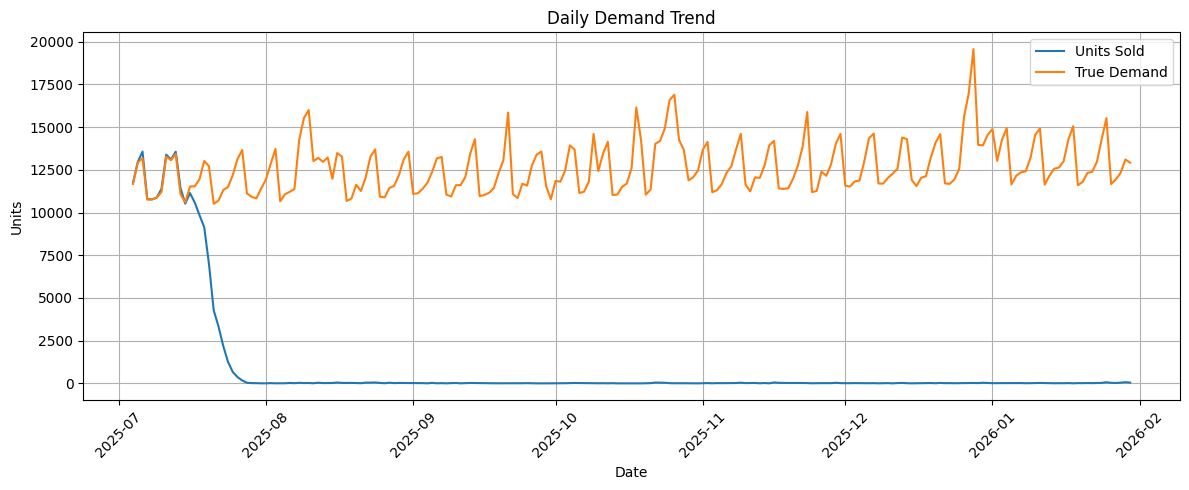

In [8]:
# demand trend chart

daily = (
    fact_sales.groupby("date", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        true_demand=("true_demand_units", "sum"),
        revenue=("revenue", "sum")
    )
    .sort_values("date")
)

plt.figure(figsize=(12, 5))
plt.plot(daily["date"], daily["units_sold"], label="Units Sold")
plt.plot(daily["date"], daily["true_demand"], label="True Demand")
plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\praga\AppData\Local\Temp\ipykernel_15136\1144266608.py:10: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  weekly["day_of_week"] = pd.Categorical(weekly["day_of_week"], categories=order, ordered=True)


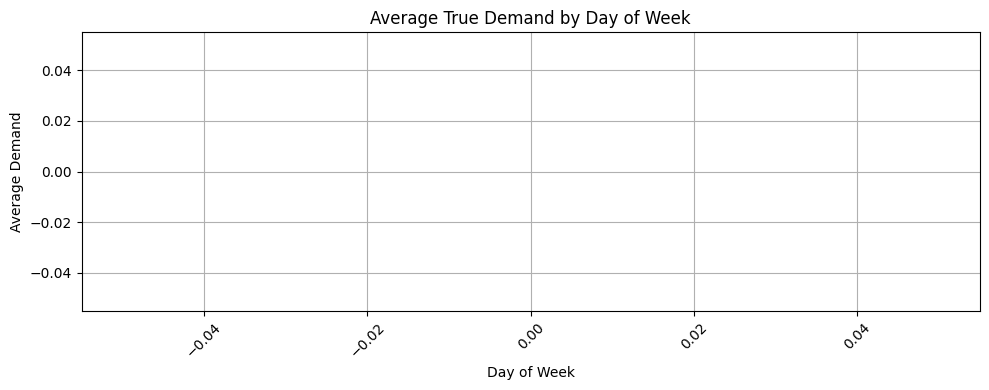

In [9]:
# weekly seasonality


weekly = (
    fact_sales.groupby("day_of_week", as_index=False)
    .agg(avg_true_demand=("true_demand_units", "mean"))
)

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekly["day_of_week"] = pd.Categorical(weekly["day_of_week"], categories=order, ordered=True)
weekly = weekly.sort_values("day_of_week")

plt.figure(figsize=(10, 4))
plt.bar(weekly["day_of_week"], weekly["avg_true_demand"])
plt.title("Average True Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
# promo / holiday effect

promo_effect = (
    fact_sales.groupby(["promo_flag", "holiday_flag"], as_index=False)
    .agg(avg_true_demand=("true_demand_units", "mean"))
)
promo_effect

,promo_flag,holiday_flag,avg_true_demand
0,0,0,7.601398
1,0,1,9.259877
2,1,0,9.071268
3,1,1,12.079630


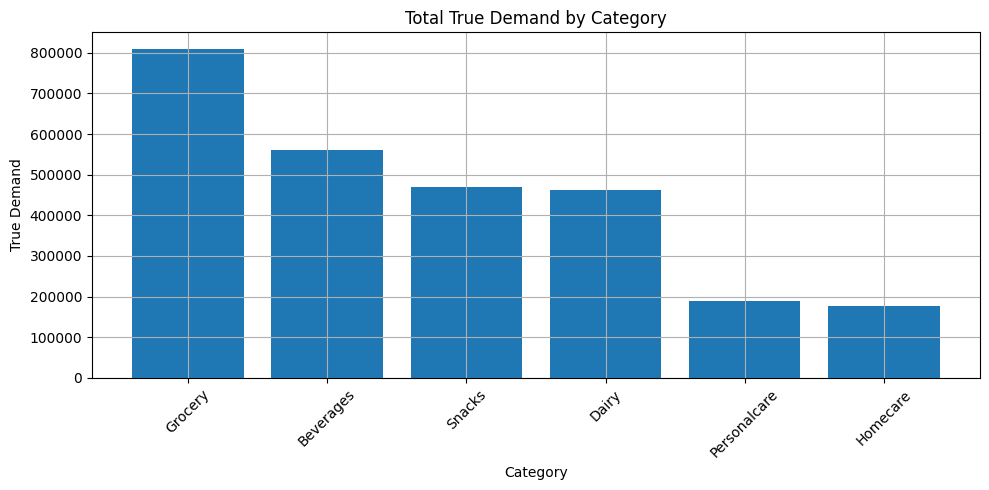

In [11]:
# top categories by demand 

cat_demand = (
    fact_sales.groupby("category", as_index=False)
    .agg(total_true_demand=("true_demand_units", "sum"))
    .sort_values("total_true_demand", ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(cat_demand["category"], cat_demand["total_true_demand"])
plt.title("Total True Demand by Category")
plt.xlabel("Category")
plt.ylabel("True Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
# forecast accuracy

forecast_overall


forecast_by_category.sort_values("regression_wape")

,category,baseline_mape,baseline_wape,regression_mape,regression_wape,better_model_by_wape
2,Grocery,1.209647,0.742314,0.748942,0.541638,regression
1,Dairy,1.201794,0.740123,0.714914,0.543159,regression
5,Snacks,1.243857,0.742355,0.802523,0.559605,regression
0,Beverages,1.328252,0.796125,0.810327,0.574948,regression
4,Personalcare,1.204635,0.883922,0.753183,0.657540,regression
3,Homecare,1.192158,0.912876,0.708185,0.668452,regression


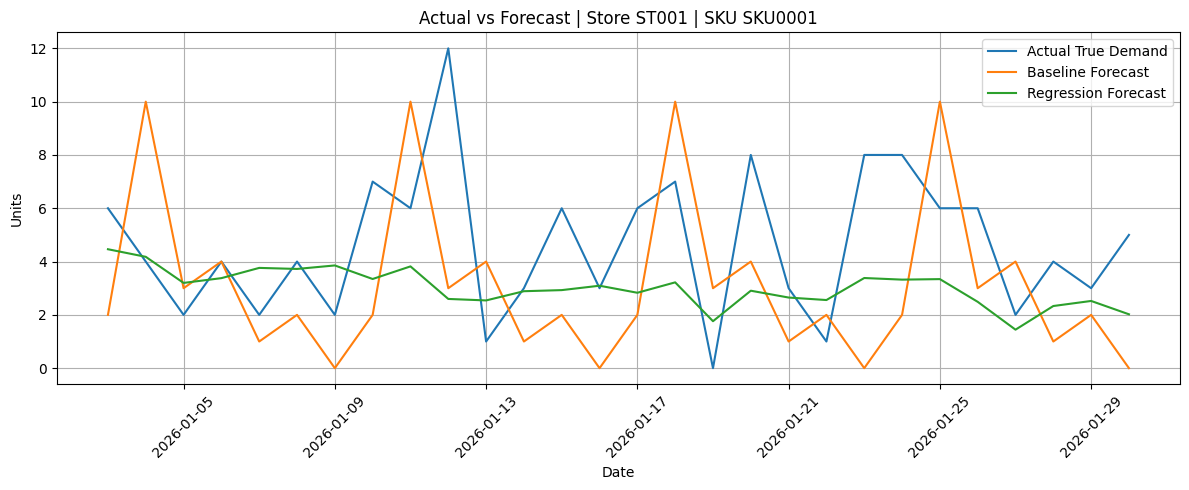

In [13]:
# Example actual vs forecast for a specific store-sku

sample = (
    forecast_detail.groupby(["store_id", "sku_id"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(1)
)

sample_store = sample.iloc[0]["store_id"]
sample_sku = sample.iloc[0]["sku_id"]

sample_df = forecast_detail[
    (forecast_detail["store_id"] == sample_store) &
    (forecast_detail["sku_id"] == sample_sku)
].sort_values("date")

plt.figure(figsize=(12, 5))
plt.plot(sample_df["date"], sample_df["actual_true_demand"], label="Actual True Demand")
plt.plot(sample_df["date"], sample_df["baseline_forecast"], label="Baseline Forecast")
plt.plot(sample_df["date"], sample_df["regression_forecast"], label="Regression Forecast")
plt.title(f"Actual vs Forecast | Store {sample_store} | SKU {sample_sku}")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# risk segmentation

risk["risk_flag"].value_counts()

risk_by_category = (
    risk.groupby(["category", "risk_flag"], as_index=False)
    .size()
)

risk_by_category

,category,risk_flag,size
0,Beverages,Healthy Zone,2
1,Beverages,Stockout Risk,358
2,Dairy,Stockout Risk,216
3,Grocery,Stockout Risk,288
4,Homecare,Stockout Risk,252
5,Personalcare,Healthy Zone,1
6,Personalcare,Stockout Risk,233
7,Snacks,Stockout Risk,270


In [15]:
# top stockout risk

stockout_top10.head(10)

,date,store_id,sku_id,region,city_tier,store_size,category_x,price,cost,shelf_life_days,...,recommended_order_qty,on_hand_units,category_y,forecast_avg_daily_demand,forecast_28d_units,category,projected_days_to_zero,doh_threshold,risk_flag,recommended_action
0,2026-01-30,ST003,SKU0019,South,1,L,Grocery,417.65,231.32,19,...,203.1643,0.0,Grocery,31.384114,878.755195,Grocery,0.0,11.4,Stockout Risk,Replenish / expedite / transfer in
1,2026-01-30,ST008,SKU0033,East,2,L,Grocery,226.20,174.20,20,...,204.8571,0.0,Grocery,28.813863,806.788174,Grocery,0.0,12.0,Stockout Risk,Replenish / expedite / transfer in
2,2026-01-30,ST003,SKU0051,South,1,L,Grocery,461.75,300.95,11,...,136.7143,0.0,Grocery,25.896481,725.101481,Grocery,0.0,6.6,Stockout Risk,Replenish / expedite / transfer in
3,2026-01-30,ST003,SKU0074,South,1,L,Grocery,133.11,99.08,10,...,115.9286,0.0,Grocery,25.892126,724.979517,Grocery,0.0,6.0,Stockout Risk,Replenish / expedite / transfer in
4,2026-01-30,ST008,SKU0074,East,2,L,Grocery,133.11,99.08,10,...,121.9286,0.0,Grocery,24.866458,696.260822,Grocery,0.0,6.0,Stockout Risk,Replenish / expedite / transfer in
5,2026-01-30,ST003,SKU0038,South,1,L,Grocery,226.47,143.55,15,...,208.6071,0.0,Grocery,22.959656,642.870355,Grocery,0.0,9.0,Stockout Risk,Replenish / expedite / transfer in
6,2026-01-30,ST003,SKU0033,South,1,L,Grocery,226.20,174.20,20,...,291.6429,0.0,Grocery,22.465216,629.026046,Grocery,0.0,12.0,Stockout Risk,Replenish / expedite / transfer in
7,2026-01-30,ST003,SKU0012,South,1,L,Dairy,241.46,163.30,18,...,175.3071,0.0,Dairy,22.279276,623.819732,Dairy,0.0,10.8,Stockout Risk,Replenish / expedite / transfer in
8,2026-01-30,ST008,SKU0085,East,2,L,Grocery,128.53,101.26,8,...,90.7714,0.0,Grocery,21.159165,592.456633,Grocery,0.0,4.8,Stockout Risk,Replenish / expedite / transfer in
9,2026-01-30,ST011,SKU0038,North,2,L,Grocery,226.47,143.55,15,...,180.6429,0.0,Grocery,21.154696,592.331488,Grocery,0.0,9.0,Stockout Risk,Replenish / expedite / transfer in


In [16]:
# top overstock risk

overstock_top10.head(10)

,date,store_id,sku_id,region,city_tier,store_size,category_x,price,cost,shelf_life_days,...,recommended_order_qty,on_hand_units,category_y,forecast_avg_daily_demand,forecast_28d_units,category,projected_days_to_zero,doh_threshold,risk_flag,recommended_action


In [17]:
# replenishment planner summary

policy[[
    "store_id", "sku_id", "category", "current_on_hand",
    "reorder_point_calc", "recommended_order_qty", "recommended_action"
]].head(20)

,store_id,sku_id,category,current_on_hand,reorder_point_calc,recommended_order_qty,recommended_action
0,ST001,SKU0001,Personalcare,0.0,37.105507,63.0,Raise PO
1,ST001,SKU0002,Homecare,0.0,40.398185,69.0,Raise PO
2,ST001,SKU0003,Snacks,0.0,70.833669,178.0,Raise PO
3,ST001,SKU0004,Snacks,0.0,78.831692,196.0,Raise PO
4,ST001,SKU0005,Beverages,0.0,61.391498,133.0,Raise PO
5,ST001,SKU0006,Dairy,0.0,98.813593,79.0,Raise PO
6,ST001,SKU0007,Dairy,0.0,105.631285,51.0,Raise PO
7,ST001,SKU0008,Beverages,0.0,80.433840,169.0,Raise PO
8,ST001,SKU0009,Homecare,0.0,27.719729,47.0,Raise PO
9,ST001,SKU0010,Homecare,0.0,35.180306,59.0,Raise PO


In [18]:
# Top PO list

po_list.head(20)




,store_id,sku_id,inventory_date,region,city_tier,store_size,category,price,cost,avg_daily_demand,...,shelf_life_days,max_storage_units,remaining_storage_capacity,should_reorder,recommended_order_qty_raw,recommended_order_qty,recommended_action,constraint_notes,recommended_order_cost_value,recommended_order_sales_value
0,ST003,SKU0058,2026-01-30,South,1,L,Snacks,630.86,470.86,13.7857,...,217,1000,1000.0,True,327.099345,328.0,Raise PO,No constraint triggered,154442.08,206922.08
1,ST003,SKU0075,2026-01-30,South,1,L,Snacks,565.89,447.02,13.4821,...,316,1000,1000.0,True,318.849217,319.0,Raise PO,No constraint triggered,142599.38,180518.91
2,ST008,SKU0075,2026-01-30,East,2,L,Snacks,565.89,447.02,13.3571,...,316,1000,1000.0,True,313.029605,314.0,Raise PO,No constraint triggered,140364.28,177689.46
3,ST011,SKU0058,2026-01-30,North,2,L,Snacks,630.86,470.86,12.2143,...,217,1000,1000.0,True,288.588726,289.0,Raise PO,No constraint triggered,136078.54,182318.54
4,ST003,SKU0004,2026-01-30,South,1,L,Snacks,539.79,385.07,14.5714,...,420,1000,1000.0,True,338.430252,339.0,Raise PO,No constraint triggered,130538.73,182988.81
5,ST008,SKU0058,2026-01-30,East,2,L,Snacks,630.86,470.86,11.6786,...,217,1000,1000.0,True,276.959281,277.0,Raise PO,No constraint triggered,130428.22,174748.22
6,ST011,SKU0075,2026-01-30,North,2,L,Snacks,565.89,447.02,12.0179,...,316,1000,1000.0,True,283.029416,284.0,Raise PO,No constraint triggered,126953.68,160712.76
7,ST008,SKU0004,2026-01-30,East,2,L,Snacks,539.79,385.07,13.6250,...,420,1000,1000.0,True,327.294491,328.0,Raise PO,No constraint triggered,126302.96,177051.12
8,ST009,SKU0058,2026-01-30,South,1,M,Snacks,630.86,470.86,10.1964,...,217,1000,1000.0,True,237.009554,238.0,Raise PO,No constraint triggered,112064.68,150144.68
9,ST009,SKU0075,2026-01-30,South,1,M,Snacks,565.89,447.02,10.8393,...,316,1000,1000.0,True,249.462670,250.0,Raise PO,No constraint triggered,111755.00,141472.50


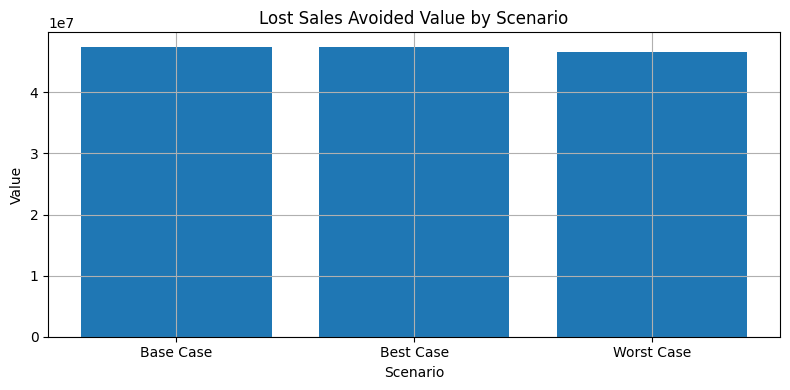

In [19]:
# Cell 17 — Impact summary by scenario

impact_summary
plt.figure(figsize=(8, 4))
plt.bar(impact_summary["scenario"], impact_summary["lost_sales_avoided_value"])
plt.title("Lost Sales Avoided Value by Scenario")
plt.xlabel("Scenario")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

In [20]:

#Cell 18 — Base case category impact

impact_category


,category,lost_sales_avoided_units,lost_sales_avoided_value,stockout_days_reduced_proxy,inventory_value_change,holding_cost_change
0,Beverages,50569.542602,1.347753e+07,8939.0,1.310911e+06,26218.224466
1,Snacks,47257.716117,1.283154e+07,7116.0,1.413394e+06,28267.888108
2,Grocery,33315.081684,7.841164e+06,3350.0,1.219125e+05,2438.249655
3,Personalcare,14421.385633,4.827679e+06,5229.0,3.752785e+05,7505.569344
4,Dairy,14933.385265,4.393502e+06,2219.0,5.819792e+04,1163.958440
5,Homecare,13717.956103,3.983675e+06,5572.0,2.783196e+05,5566.392591


In [21]:
# Cell 19 — Top impact SKUs

top_impact.head(20)

,store_id,sku_id,category,region,city_tier,store_size,on_hand_close,recommended_order_qty,scenario_lost_sales_avoided_units,scenario_lost_sales_avoided_value,scenario_stockout_days_reduced,scenario_inventory_value_change,scenario_holding_cost_change,recommended_action
0,ST003,SKU0058,Snacks,South,1,L,0.0,328.0,328.000000,206922.080000,27.0,0.000000,0.000000,Raise PO
1,ST003,SKU0004,Snacks,South,1,L,0.0,339.0,339.000000,182988.810000,23.0,0.000000,0.000000,Raise PO
2,ST003,SKU0075,Snacks,South,1,L,0.0,319.0,319.000000,180518.910000,29.0,0.000000,0.000000,Raise PO
3,ST008,SKU0004,Snacks,East,2,L,0.0,328.0,328.000000,177051.120000,26.0,0.000000,0.000000,Raise PO
4,ST008,SKU0058,Snacks,East,2,L,0.0,277.0,277.000000,174748.220000,18.0,0.000000,0.000000,Raise PO
5,ST008,SKU0075,Snacks,East,2,L,0.0,314.0,301.311065,170508.918372,30.0,5672.207882,113.444158,Raise PO
6,ST011,SKU0075,Snacks,North,2,L,0.0,284.0,284.000000,160712.760000,26.0,0.000000,0.000000,Raise PO
7,ST009,SKU0058,Snacks,South,1,M,0.0,238.0,223.802247,141187.885451,30.0,6685.154046,133.703081,Raise PO
8,ST011,SKU0004,Snacks,North,2,L,0.0,268.0,257.221660,138845.679704,30.0,4150.415489,83.008310,Raise PO
9,ST009,SKU0075,Snacks,South,1,M,0.0,250.0,235.305212,133156.866332,30.0,6568.864200,131.377284,Raise PO


## Key Conclusions

- Demand shows measurable weekly variation and promo/holiday sensitivity.
- Regression forecast can be compared with baseline using WAPE/MAPE.
- Stockout and overstock risks are concentrated in a subset of store-SKU combinations.
- Replenishment policy uses safety stock, reorder point, MOQ, shelf-life, and storage constraints.
- Scenario analysis estimates the business upside through lost-sales avoided and stockout-days reduced.